# StochastiQ — Notebook 04: Monte Carlo Simulation and Model-Robust Portfolio Optimization

**Project:** StochastiQ — Multi-model portfolio optimization and derivatives strategy framework  
**Course:** MGT 6081 Derivative Securities, Georgia Institute of Technology  
**Author:** Anay Abhijit Joshi

---

## Objectives

Phase 3 calibrated four stochastic models — GBM, Merton, CEV, Heston — to each of the seven assets in the universe. Each model produces a different distribution of forward asset returns, and (crucially) each model's distribution implies a different optimal portfolio. **No single model is universally correct**; the Phase 3 goodness-of-fit results made this explicit. 

Phase 4 addresses the natural follow-up question: **how do we choose portfolio weights when we don't know which model is right?**

We answer in three steps:

1. **Joint Monte Carlo simulation** of all 7 assets under each of the 4 calibrated models, preserving cross-asset correlation structure via Cholesky decomposition of the empirical correlation matrix.

2. **Per-model optimal portfolios** — solve for the max-Sharpe portfolio under each model's simulated distribution. Compare the 4 portfolios to see how much they disagree.

3. **Three model-robust portfolios** that hedge against model misspecification:
   - **Min-max Sharpe robust** — maximize the worst-case Sharpe across the 4 models. This is robust optimization in the Ben-Tal/Nemirovski sense.
   - **Equal-blend** — pool the 4 model distributions with equal weights and optimize on the blended distribution.
   - **KS-weighted blend** — Bayesian-style averaging weighted by each model's empirical KS p-value from Phase 3.

All optimizations enforce realistic institutional constraints: long-only, 30% max single-asset weight, fully invested.

## The Headline Question

Does model-robust optimization produce *materially better* worst-case performance than naive single-model optimization? If yes, that justifies the complexity of the multi-model framework. We'll find out by cross-evaluating every portfolio under every model's distribution.

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RISK_FREE_RATE, TRADING_DAYS, RANDOM_SEED, DEFAULT_N_PATHS
from src.data.loaders import load_dataset
from src.models.gbm import GBMParams
from src.models.merton import MertonParams
from src.models.cev import CEVParams
from src.models.heston import HestonParams
from src.simulation.monte_carlo import (
    cholesky_factor,
    simulate_all_models,
    paths_to_returns,
    paths_to_terminal_returns,
)
from src.optimization.robust import (
    portfolio_stats,
    optimize_max_sharpe,
    optimize_minmax_sharpe,
    optimize_blended,
    optimize_ks_weighted,
    evaluate_under_all_models,
    MAX_WEIGHT,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Phase 4 simulation parameters
TRAIN_TEST_SPLIT = pd.Timestamp("2024-12-31")
FORECAST_HORIZON_DAYS = 252      # 1 year forward
N_PATHS = 5000                   # Number of Monte Carlo paths
HORIZON_YEARS = FORECAST_HORIZON_DAYS / TRADING_DAYS

print(f"Project root:           {PROJECT_ROOT}")
print(f"Forecast horizon:       {FORECAST_HORIZON_DAYS} days ({HORIZON_YEARS:.2f} year)")
print(f"Monte Carlo paths:      {N_PATHS:,}")
print(f"Max single-asset weight: {MAX_WEIGHT:.0%}")
print(f"Risk-free rate:         {RISK_FREE_RATE:.1%}")

Project root:           /Users/anayjoshi/Downloads/StochastiQ
Forecast horizon:       252 days (1.00 year)
Monte Carlo paths:      5,000
Max single-asset weight: 30%
Risk-free rate:         4.0%


## 2. Load Calibrated Parameters and Historical Data

We load the calibrated parameters from Phase 3 and reconstruct the calibrated parameter objects. We also load the historical price and return data to compute the empirical cross-asset correlation matrix used for joint simulation.

In [2]:
# Load Phase 3 outputs
params_df = pd.read_parquet(PROCESSED_DIR / "calibrated_parameters.parquet")
fit_df    = pd.read_parquet(PROCESSED_DIR / "goodness_of_fit.parquet")

# Load price and return data
prices_full      = load_dataset(PROCESSED_DIR / "prices.parquet")
log_returns_full = load_dataset(PROCESSED_DIR / "log_returns.parquet")
tickers = list(log_returns_full.columns)

# Use training-window data (consistent with Phase 3 calibration)
log_returns_train = log_returns_full.loc[:TRAIN_TEST_SPLIT]

# Reconstruct calibrated objects from primary calibrations only
primary = params_df[params_df["variant"] == "primary"]

calibrated = {}
for ticker in tickers:
    calibrated[ticker] = {}
    for model in ["GBM", "Merton", "CEV", "Heston"]:
        rows = primary[(primary["ticker"] == ticker) & (primary["model"] == model)]
        param_kwargs = dict(zip(rows["param"], rows["value"]))
        if model == "GBM":
            calibrated[ticker][model] = GBMParams(**param_kwargs)
        elif model == "Merton":
            calibrated[ticker][model] = MertonParams(
                mu=param_kwargs["mu"], sigma=param_kwargs["sigma"],
                lambda_j=param_kwargs["lambda_j"],
                mu_j=param_kwargs["mu_j"], sigma_j=param_kwargs["sigma_j"],
            )
        elif model == "CEV":
            calibrated[ticker][model] = CEVParams(**param_kwargs)
        elif model == "Heston":
            calibrated[ticker][model] = HestonParams(
                mu=param_kwargs["mu"], kappa=param_kwargs["kappa"],
                theta=param_kwargs["theta"], sigma_v=param_kwargs["sigma_v"],
                rho=param_kwargs["rho"], v0=param_kwargs["v0"],
            )

print(f"Loaded calibrations for {len(calibrated)} assets x 4 models = {len(calibrated) * 4} parameter sets")
print(f"Training data range: {log_returns_train.index.min().date()} to {log_returns_train.index.max().date()}")
print(f"Assets ({len(tickers)}): {tickers}")

Loaded calibrations for 7 assets x 4 models = 28 parameter sets
Training data range: 2020-01-03 to 2024-12-31
Assets (7): ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'SPY', 'GLD']


## 3. Empirical Cross-Asset Correlation Structure

Each Phase 3 model is calibrated marginally per asset (no cross-asset coupling). For portfolio optimization we need the joint distribution. We use the empirical correlation matrix from training-window log returns and inject it into the simulator via Cholesky decomposition.

This is the standard approach for production risk systems (Glasserman, _Monte Carlo Methods in Financial Engineering_, 2003): each model's marginal behavior is preserved, while cross-asset dependence is enforced through correlated Brownian increments.

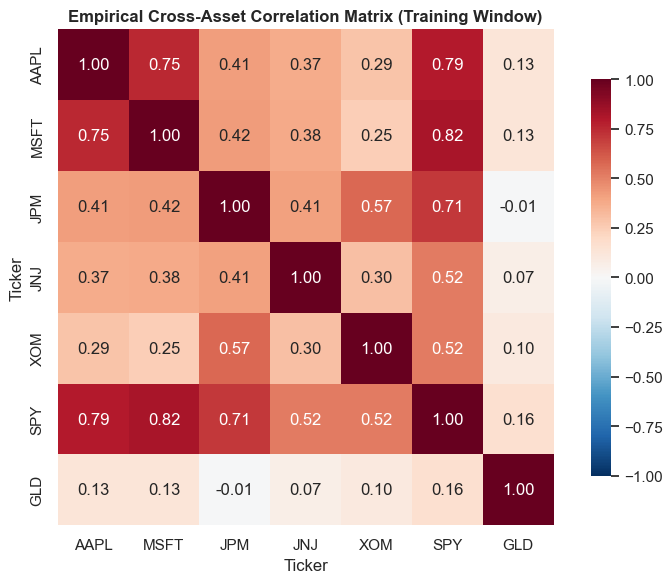


Cholesky factor shape: (7, 7)
Max reconstruction error: 1.11e-16


In [3]:
# Empirical correlation matrix (training window only)
R = log_returns_train.corr()
L = cholesky_factor(R.values)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    R, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Empirical Cross-Asset Correlation Matrix (Training Window)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print(f"\nCholesky factor shape: {L.shape}")
print(f"Max reconstruction error: {np.max(np.abs(L @ L.T - R.values)):.2e}")

**Reading the heatmap:** Equity assets cluster in a tight 0.4–0.7 correlation band — they all move together with the broader market. GLD shows near-zero correlation with everything else, which is exactly its role in the universe (crisis hedge / portfolio diversifier). This structure justifies the multi-asset framework: there's real diversification benefit available.

## 4. Joint Monte Carlo Simulation Under Each Model

We simulate **5,000 paths** of joint asset prices over a **1-year horizon** under each of the four calibrated models. Initial prices are taken as of the training-window cutoff (2024-12-31). The same Cholesky factor and base seed are used across all four models, so simulated paths are directly comparable.

_Total computation: 4 models × 5,000 paths × 252 days × 7 assets ≈ 35M random draws. Runtime ~30-60 seconds._

In [4]:
# Initial prices: training-window endpoint
s0 = prices_full.loc[:TRAIN_TEST_SPLIT].iloc[-1].values
print(f"Initial prices (S_0):")
for ticker, price in zip(tickers, s0):
    print(f"  {ticker}: ${price:.2f}")
print()

# Run joint MC simulation under all four models
paths_by_model = simulate_all_models(
    s0=s0,
    calibrated=calibrated,
    tickers=tickers,
    correlation_matrix=R.values,
    horizon_days=FORECAST_HORIZON_DAYS,
    n_paths=N_PATHS,
    trading_days=TRADING_DAYS,
    seed=RANDOM_SEED,
)

print(f"Simulation complete. Path arrays:")
for model, paths in paths_by_model.items():
    mb = paths.nbytes / (1024 ** 2)
    print(f"  {model}: shape={paths.shape}, memory={mb:.1f} MB")

Initial prices (S_0):
  AAPL: $249.06
  MSFT: $417.46
  JPM: $232.50
  JNJ: $139.58
  XOM: $103.07
  SPY: $577.70
  GLD: $242.13

Simulation complete. Path arrays:
  GBM: shape=(5000, 253, 7), memory=67.6 MB
  Merton: shape=(5000, 253, 7), memory=67.6 MB
  CEV: shape=(5000, 253, 7), memory=67.6 MB
  Heston: shape=(5000, 253, 7), memory=67.6 MB


### 4.1 Sanity Check: Cross-Asset Correlation Preserved

We verify that simulated path correlations match the target empirical correlation. If the Cholesky injection works correctly, simulated correlations should be within Monte Carlo error of the empirical values for all four models.

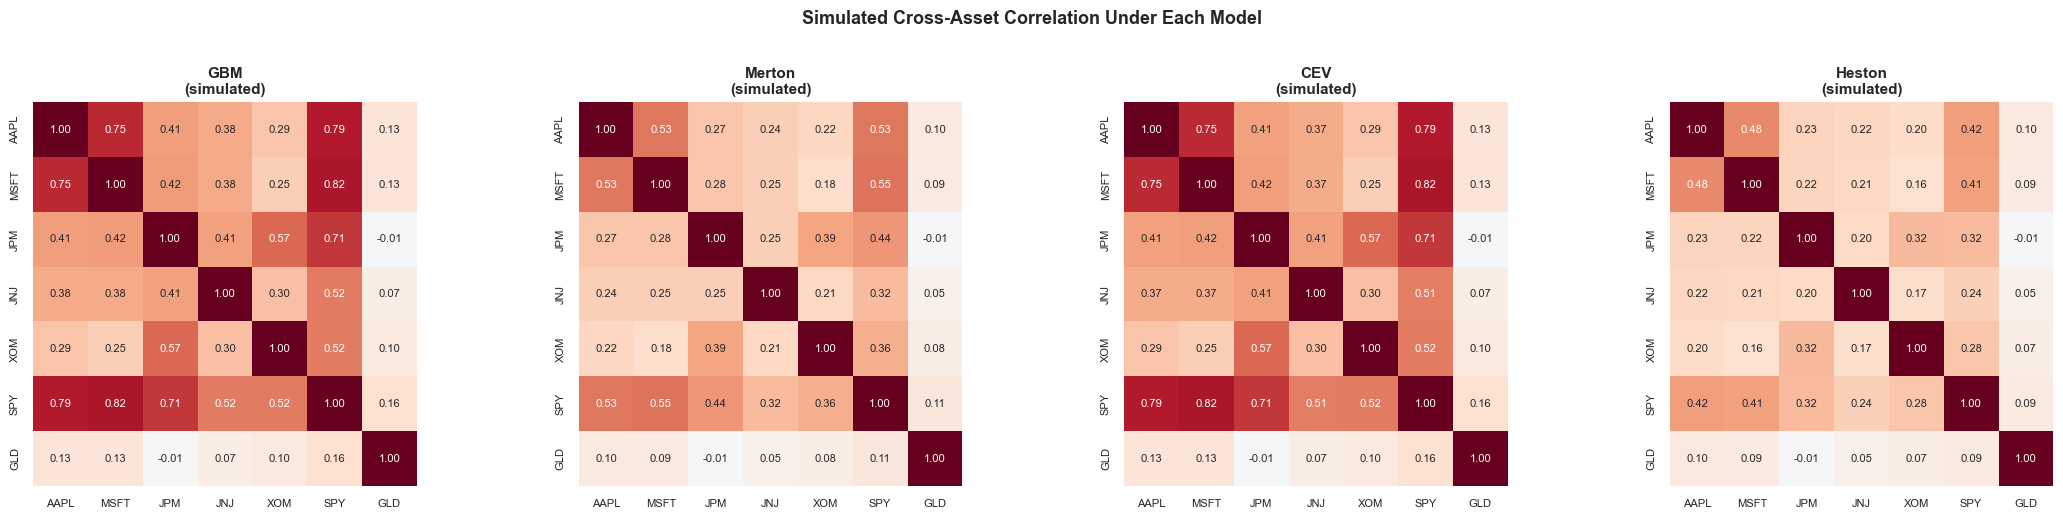

In [5]:
# Compute simulated cross-asset correlations from each model's paths
model_names = ["GBM", "Merton", "CEV", "Heston"]

sim_corr_check = pd.DataFrame(index=tickers, columns=tickers + [""], dtype=float)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, model in enumerate(model_names):
    daily_rets = paths_to_returns(paths_by_model[model])  # (n_paths, n_steps, n_assets)
    flat_rets = daily_rets.reshape(-1, len(tickers))
    R_sim = pd.DataFrame(
        np.corrcoef(flat_rets, rowvar=False),
        index=tickers, columns=tickers,
    )
    sns.heatmap(
        R_sim, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, square=True, ax=axes[i],
        cbar=False, annot_kws={"size": 8},
    )
    axes[i].set_title(f"{model}\n(simulated)", fontsize=11, fontweight="bold")
    axes[i].tick_params(labelsize=8)

plt.suptitle("Simulated Cross-Asset Correlation Under Each Model", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_simulated_correlations.png", bbox_inches="tight")
plt.show()

### 4.2 Terminal Return Distributions Under Each Model

We extract the **total log return** for each path over the full 1-year horizon. These per-path terminal returns are what portfolio optimization will use — each path represents one possible 1-year outcome.

We plot the simulated terminal-return distribution for SPY (as a representative diversified asset) under each model. Differences across models tell us *how* the models disagree.

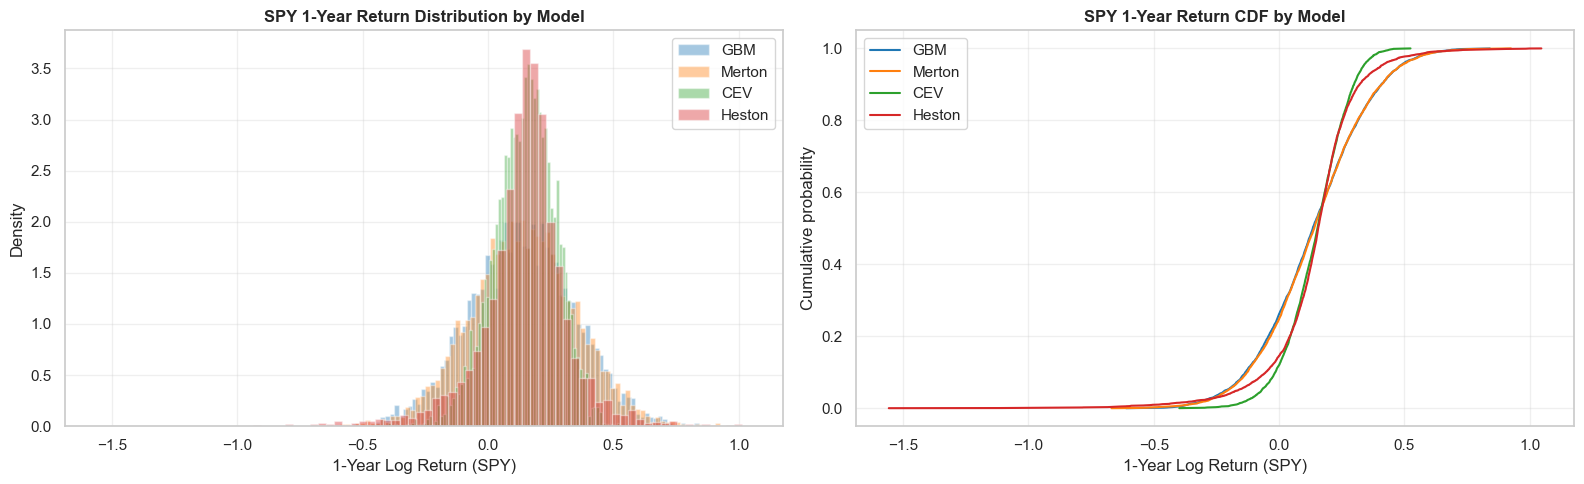

In [6]:
# Terminal returns under each model
terminal_returns = {m: paths_to_terminal_returns(p) for m, p in paths_by_model.items()}

# Plot terminal return distribution for SPY
spy_idx = tickers.index("SPY")
model_colors = {"GBM": "#1f77b4", "Merton": "#ff7f0e", "CEV": "#2ca02c", "Heston": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram comparison
for model in model_names:
    axes[0].hist(
        terminal_returns[model][:, spy_idx],
        bins=80, alpha=0.4, label=model,
        color=model_colors[model], density=True,
    )
axes[0].set_xlabel("1-Year Log Return (SPY)")
axes[0].set_ylabel("Density")
axes[0].set_title("SPY 1-Year Return Distribution by Model", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Empirical CDF
for model in model_names:
    sorted_rets = np.sort(terminal_returns[model][:, spy_idx])
    cdf = np.linspace(0, 1, len(sorted_rets))
    axes[1].plot(sorted_rets, cdf, label=model, color=model_colors[model], linewidth=1.5)
axes[1].set_xlabel("1-Year Log Return (SPY)")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("SPY 1-Year Return CDF by Model", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_spy_distribution.png", bbox_inches="tight")
plt.show()

**Reading these plots:**
- **GBM (blue)** is the thinnest-tailed: log-normal returns by construction.
- **Merton (orange)** has visibly fatter left tail from the explicit jump component.
- **CEV (green)** shows slight left skew from the leverage effect (volatility rises as price falls).
- **Heston (red)** captures fat tails through stochastic volatility — wider than GBM but no discrete jumps.

Where these distributions diverge in the lower tail is exactly where portfolio optimization will produce different weights. A risk-averse optimizer that takes Merton seriously will hold less of an asset than one that assumes GBM.

## 5. Per-Asset Summary Statistics by Model

Before optimizing portfolios, we summarize what each model predicts for each asset on a 1-year horizon.

In [7]:
# Per-asset, per-model: mean return, vol, 5% VaR
rows = []
for model in model_names:
    ret = terminal_returns[model]  # (n_paths, n_assets)
    for j, ticker in enumerate(tickers):
        rows.append({
            "Model":  model,
            "Asset":  ticker,
            "Mean":   ret[:, j].mean(),
            "Vol":    ret[:, j].std(ddof=1),
            "VaR_5%": np.percentile(ret[:, j], 5),
        })

asset_summary = pd.DataFrame(rows)
asset_summary_pivot = asset_summary.pivot_table(
    index="Asset", columns="Model", values=["Mean", "Vol", "VaR_5%"]
).reindex(tickers)

asset_summary_pivot.style.format("{:.2%}")

## 6. Per-Model Optimal Portfolios

We now solve for the **max-Sharpe portfolio** under each model's distribution independently. Constraints:
- Long-only ($w_i \geq 0$)
- Concentration cap ($w_i \leq 30\%$)
- Fully invested ($\sum w_i = 1$)

These are realistic institutional IPS constraints — far more defensible than the unconstrained Phase 2 portfolios that landed at ~62% GLD.

In [8]:
per_model_weights = {}
for model in model_names:
    w = optimize_max_sharpe(
        terminal_returns[model],
        rf=RISK_FREE_RATE,
        horizon_years=HORIZON_YEARS,
        max_weight=MAX_WEIGHT,
    )
    per_model_weights[model] = w

weights_df = pd.DataFrame(per_model_weights, index=tickers)
print("Per-model max-Sharpe weights (constraints: long-only, 30% max, sum to 1):\n")
weights_df.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None, vmin=0, vmax=MAX_WEIGHT)

Per-model max-Sharpe weights (constraints: long-only, 30% max, sum to 1):



,GBM,Merton,CEV,Heston
AAPL,30.0%,30.0%,30.0%,30.0%
MSFT,26.3%,20.1%,19.4%,14.2%
JPM,4.0%,6.2%,26.0%,6.5%
JNJ,0.0%,0.0%,0.0%,0.0%
XOM,9.8%,6.3%,0.0%,9.4%
SPY,0.0%,7.3%,0.0%,10.0%
GLD,30.0%,30.0%,24.6%,30.0%


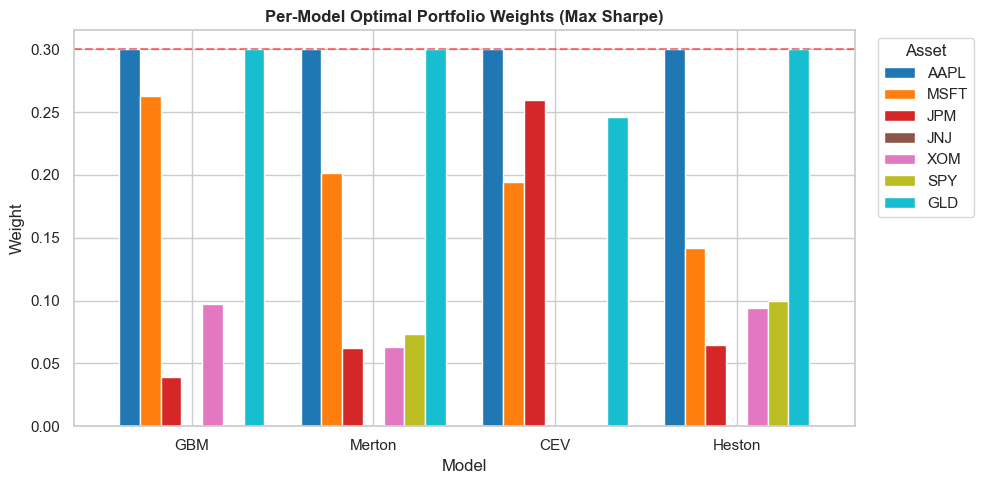

In [9]:
# Visualize per-model weights as a stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
weights_df.T.plot(kind="bar", stacked=False, ax=ax, width=0.8, colormap="tab10")
ax.set_xlabel("Model")
ax.set_ylabel("Weight")
ax.set_title("Per-Model Optimal Portfolio Weights (Max Sharpe)", fontweight="bold")
ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, MAX_WEIGHT * 1.05)
ax.axhline(y=MAX_WEIGHT, color="red", linestyle="--", alpha=0.5, label=f"{MAX_WEIGHT:.0%} cap")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_per_model_weights.png", bbox_inches="tight")
plt.show()

**Reading the bar chart:** Where the four models *agree* on a weight (similar bar heights for the same asset), confidence in that allocation is high. Where they *disagree* (differing bar heights), the choice depends on which model you believe — exactly the situation that motivates robust optimization.

## 7. Robust Portfolio Optimization

We construct three portfolios that hedge against model misspecification:

### 7.1 Min-Max Sharpe Robust

Maximize the **worst-case** Sharpe ratio across the four models:
$$\max_{w} \min_{m \in \{GBM, Merton, CEV, Heston\}} \text{Sharpe}_m(w)$$

Subject to the same long-only / concentration / fully invested constraints. This is robust optimization in the strict sense: regardless of which model is correct, the resulting portfolio achieves at least the optimum's worst-case Sharpe.

In [10]:
returns_list = [terminal_returns[m] for m in model_names]

w_minmax = optimize_minmax_sharpe(
    returns_list,
    rf=RISK_FREE_RATE,
    horizon_years=HORIZON_YEARS,
    max_weight=MAX_WEIGHT,
)

print("Min-max Sharpe robust weights:")
for ticker, w in zip(tickers, w_minmax):
    bar = "█" * int(round(w * 50))
    print(f"  {ticker}: {w:.1%}  {bar}")

Min-max Sharpe robust weights:
  AAPL: 30.0%  ███████████████
  MSFT: 26.3%  █████████████
  JPM: 4.0%  ██
  JNJ: 0.0%  
  XOM: 9.8%  █████
  SPY: 0.0%  
  GLD: 30.0%  ███████████████


### 7.2 Equal-Blend

Pool the four models' simulated terminal returns with equal weights and optimize on the blended distribution. This is the simplest form of model averaging: each model contributes 1/4 of the sample.

In [11]:
w_blend = optimize_blended(
    returns_list,
    rf=RISK_FREE_RATE,
    horizon_years=HORIZON_YEARS,
    max_weight=MAX_WEIGHT,
)

print("Equal-blend weights:")
for ticker, w in zip(tickers, w_blend):
    bar = "█" * int(round(w * 50))
    print(f"  {ticker}: {w:.1%}  {bar}")

Equal-blend weights:
  AAPL: 30.0%  ███████████████
  MSFT: 21.5%  ███████████
  JPM: 8.2%  ████
  JNJ: 0.0%  
  XOM: 10.3%  █████
  SPY: 0.0%  
  GLD: 30.0%  ███████████████


### 7.3 KS-Weighted Blend

Weight each model's contribution to the blend by its average out-of-sample KS p-value from Phase 3. Models that fit historical returns better get more influence in the optimization. This is a Bayesian model averaging approach, where the KS p-value serves as evidence for the model's pertinence.

In [12]:
# Average KS p-value per model (across all 7 assets)
mean_ks_p = (
    fit_df.groupby("model")["KS_pvalue"].mean()
    .reindex(model_names)
)
print("Mean out-of-sample KS p-value per model (from Phase 3):")
for m, p in mean_ks_p.items():
    print(f"  {m}: {p:.4f}")
print()

# Normalized blend weights
ks_weights = mean_ks_p.values / mean_ks_p.values.sum()
print("Normalized blend weights:")
for m, w in zip(model_names, ks_weights):
    print(f"  {m}: {w:.1%}")
print()

w_ks = optimize_ks_weighted(
    returns_list,
    ks_pvalues=mean_ks_p.values,
    rf=RISK_FREE_RATE,
    horizon_years=HORIZON_YEARS,
    max_weight=MAX_WEIGHT,
)

print("\nKS-weighted blend portfolio weights:")
for ticker, w in zip(tickers, w_ks):
    bar = "█" * int(round(w * 50))
    print(f"  {ticker}: {w:.1%}  {bar}")

Mean out-of-sample KS p-value per model (from Phase 3):
  GBM: 0.0001
  Merton: 0.0014
  CEV: 0.0666
  Heston: 0.0113

Normalized blend weights:
  GBM: 0.1%
  Merton: 1.7%
  CEV: 83.9%
  Heston: 14.3%


KS-weighted blend portfolio weights:
  AAPL: 30.0%  ███████████████
  MSFT: 22.3%  ███████████
  JPM: 17.5%  █████████
  JNJ: 0.0%  
  XOM: 3.1%  ██
  SPY: 0.0%  
  GLD: 27.1%  ██████████████


## 8. Cross-Evaluation: All Portfolios Under All Models

The decisive test: take every portfolio (4 per-model + 3 robust = 7 total) and evaluate its performance under every model's distribution. The resulting 7×4 grid of Sharpe ratios tells us which method gives the most reliable performance across model regimes.

In [13]:
all_portfolios = {
    "Per-GBM":      per_model_weights["GBM"],
    "Per-Merton":   per_model_weights["Merton"],
    "Per-CEV":      per_model_weights["CEV"],
    "Per-Heston":   per_model_weights["Heston"],
    "Min-max":      w_minmax,
    "Equal-blend":  w_blend,
    "KS-weighted":  w_ks,
}

# Build cross-evaluation: rows are portfolios, columns are models, values are Sharpes
cross_sharpe = pd.DataFrame(index=list(all_portfolios.keys()), columns=model_names, dtype=float)
cross_cvar = pd.DataFrame(index=list(all_portfolios.keys()), columns=model_names, dtype=float)

for portfolio_name, w in all_portfolios.items():
    ev = evaluate_under_all_models(
        w, terminal_returns,
        rf=RISK_FREE_RATE, horizon_years=HORIZON_YEARS,
    )
    cross_sharpe.loc[portfolio_name] = ev["sharpe"]
    cross_cvar.loc[portfolio_name] = ev["cvar_95"]

# Add summary columns
cross_sharpe["Worst case"] = cross_sharpe[model_names].min(axis=1)
cross_sharpe["Mean"]       = cross_sharpe[model_names].mean(axis=1)
cross_sharpe["Range"]      = cross_sharpe[model_names].max(axis=1) - cross_sharpe[model_names].min(axis=1)

print("Sharpe ratio cross-evaluation:")
print("  Each row is a portfolio; each column is the model under which we evaluate.")
print("  'Worst case' is the headline metric for robust optimization.\n")
cross_sharpe.style.format("{:.3f}")\
    .background_gradient(cmap="RdYlGn", subset=model_names, axis=None)\
    .background_gradient(cmap="Greens", subset=["Worst case", "Mean"])\
    .background_gradient(cmap="Reds", subset=["Range"])

Sharpe ratio cross-evaluation:
  Each row is a portfolio; each column is the model under which we evaluate.
  'Worst case' is the headline metric for robust optimization.



,GBM,Merton,CEV,Heston,Worst case,Mean,Range
Per-GBM,0.710,0.777,1.406,0.987,0.710,0.970,0.696
Per-Merton,0.703,0.781,1.398,1.000,0.703,0.970,0.695
Per-CEV,0.669,0.732,1.460,0.937,0.669,0.950,0.791
Per-Heston,0.697,0.777,1.379,1.006,0.697,0.965,0.682
Min-max,0.710,0.777,1.406,0.987,0.710,0.970,0.696
Equal-blend,0.708,0.778,1.415,0.996,0.708,0.974,0.708
KS-weighted,0.692,0.762,1.451,0.973,0.692,0.970,0.759


**Reading the table:**
- **Worst case** column tells us the worst Sharpe each portfolio achieves across the 4 models. Higher = more robust to model misspecification.
- **Mean** column tells us average Sharpe across models. Higher = better on average.
- **Range** column tells us how much the portfolio's Sharpe varies depending on which model is correct. Lower = more model-agnostic.

The robust methods (Min-max, Equal-blend, KS-weighted) should dominate the per-model methods on the *Worst case* column — that's the academic justification for the multi-model framework.

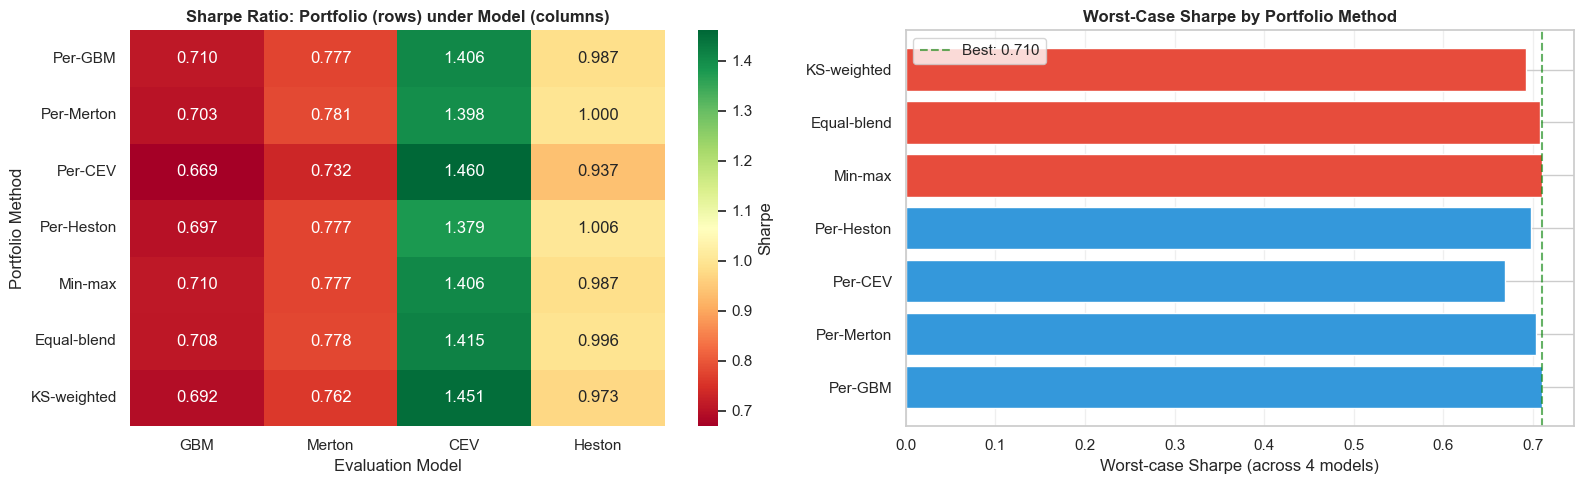

In [14]:
# Visualize the cross-evaluation as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    cross_sharpe[model_names].astype(float), annot=True, fmt=".3f",
    cmap="RdYlGn", ax=axes[0], cbar_kws={"label": "Sharpe"},
)
axes[0].set_title("Sharpe Ratio: Portfolio (rows) under Model (columns)", fontweight="bold")
axes[0].set_xlabel("Evaluation Model")
axes[0].set_ylabel("Portfolio Method")

# Worst-case Sharpe bar chart
worst = cross_sharpe["Worst case"].astype(float)
colors = ["#3498db" if "Per-" in name else "#e74c3c" for name in worst.index]
axes[1].barh(worst.index, worst.values, color=colors)
axes[1].set_xlabel("Worst-case Sharpe (across 4 models)")
axes[1].set_title("Worst-Case Sharpe by Portfolio Method", fontweight="bold")
axes[1].axvline(x=worst.max(), color="green", linestyle="--", alpha=0.6, label=f"Best: {worst.max():.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_cross_evaluation.png", bbox_inches="tight")
plt.show()

## 9. Headline Comparison: Per-Model Average vs Robust

We aggregate the per-model results (averaging across the 4 single-model Sharpes) and compare against the three robust methods. This is the cleanest summary of whether the robust framework adds value.

In [15]:
per_model_methods = ["Per-GBM", "Per-Merton", "Per-CEV", "Per-Heston"]
robust_methods = ["Min-max", "Equal-blend", "KS-weighted"]

summary_table = pd.DataFrame({
    "Worst-case Sharpe": cross_sharpe["Worst case"],
    "Mean Sharpe":       cross_sharpe["Mean"],
    "Sharpe Range":      cross_sharpe["Range"],
    "Mean CVaR_95":      cross_cvar.mean(axis=1),
})

# Add aggregated rows
agg_per_model = summary_table.loc[per_model_methods].mean()
agg_per_model.name = "Per-model AVG"
summary_with_agg = pd.concat([summary_table, agg_per_model.to_frame().T])

print("Headline comparison: per-model methods vs robust methods\n")
summary_with_agg.style.format({
    "Worst-case Sharpe": "{:.3f}",
    "Mean Sharpe":       "{:.3f}",
    "Sharpe Range":      "{:.3f}",
    "Mean CVaR_95":      "{:.2%}",
}).background_gradient(cmap="Greens", subset=["Worst-case Sharpe", "Mean Sharpe"])\
  .background_gradient(cmap="Reds_r", subset=["Sharpe Range"])\
  .background_gradient(cmap="Reds_r", subset=["Mean CVaR_95"])

Headline comparison: per-model methods vs robust methods



,Worst-case Sharpe,Mean Sharpe,Sharpe Range,Mean CVaR_95
Per-GBM,0.710,0.970,0.696,-15.83%
Per-Merton,0.703,0.970,0.695,-15.11%
Per-CEV,0.669,0.950,0.791,-16.76%
Per-Heston,0.697,0.965,0.682,-14.65%
Min-max,0.710,0.970,0.696,-15.83%
Equal-blend,0.708,0.974,0.708,-15.19%
KS-weighted,0.692,0.970,0.759,-15.85%
Per-model AVG,0.695,0.964,0.716,-15.59%


## 10. Portfolio Comparison Visualization

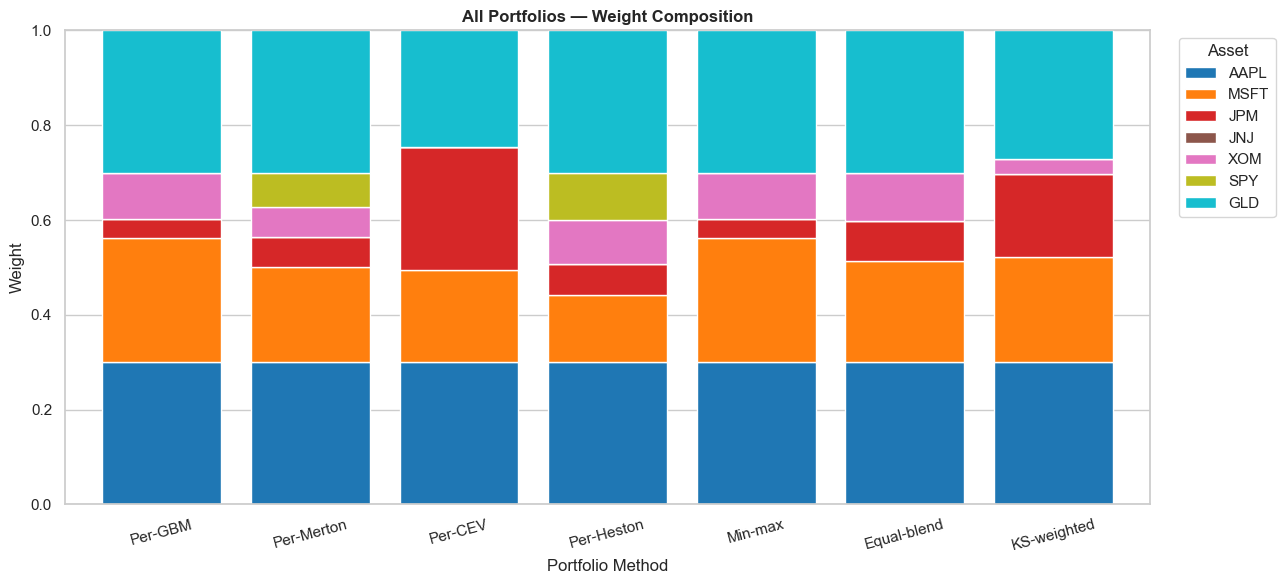

In [16]:
# All weights side by side
all_weights_df = pd.DataFrame(all_portfolios, index=tickers)

fig, ax = plt.subplots(figsize=(13, 6))
all_weights_df.T.plot(kind="bar", stacked=True, ax=ax, width=0.8, colormap="tab10")
ax.set_xlabel("Portfolio Method")
ax.set_ylabel("Weight")
ax.set_title("All Portfolios — Weight Composition", fontweight="bold")
ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_all_weights.png", bbox_inches="tight")
plt.show()

## 11. Drawdown and Tail Risk Analysis

We compute drawdown and tail-risk metrics for the robust portfolio under each model. This is the institutional risk lens: even if Sharpe is good, what does the worst 5% of paths look like?

In [17]:
def portfolio_path_stats(weights: np.ndarray, paths: np.ndarray) -> dict:
    """
    Compute path-level stats for a portfolio: max drawdown distribution.
    
    paths: (n_paths, n_steps + 1, n_assets)
    Returns: dict with max_dd_mean, max_dd_5pct (worst 5% paths)
    """
    # Portfolio NAV per path: assume rebalance-at-start, then hold (path-level NAV)
    # NAV_t / NAV_0 = sum_i w_i * (S_i_t / S_i_0)
    initial_prices = paths[:, 0, :]                       # (n_paths, n_assets)
    price_ratios = paths / initial_prices[:, np.newaxis, :]  # (n_paths, n_steps+1, n_assets)
    portfolio_nav = (price_ratios * weights).sum(axis=2)  # (n_paths, n_steps+1)

    # Running maximum and drawdown per path
    running_max = np.maximum.accumulate(portfolio_nav, axis=1)
    dd = portfolio_nav / running_max - 1.0                # (n_paths, n_steps+1), <= 0
    max_dd_per_path = dd.min(axis=1)                       # (n_paths,)

    return {
        "max_dd_mean":  float(max_dd_per_path.mean()),
        "max_dd_5pct":  float(np.percentile(max_dd_per_path, 5)),
        "max_dd_worst": float(max_dd_per_path.min()),
    }


# Compute for all 7 portfolios under all 4 models
dd_rows = []
for portfolio_name, w in all_portfolios.items():
    for model in model_names:
        stats = portfolio_path_stats(w, paths_by_model[model])
        dd_rows.append({
            "Portfolio":   portfolio_name,
            "Model":       model,
            **stats,
        })

dd_long = pd.DataFrame(dd_rows)

# Worst-case max-DD per portfolio (over all models)
worst_dd = dd_long.groupby("Portfolio")["max_dd_5pct"].min().reindex(list(all_portfolios.keys()))
mean_dd  = dd_long.groupby("Portfolio")["max_dd_mean"].mean().reindex(list(all_portfolios.keys()))

dd_summary = pd.DataFrame({
    "Mean Max-DD (avg over models)":       mean_dd,
    "Worst-case 5%-tail Max-DD":           worst_dd,
})

print("Drawdown summary (negative = drawdown; smaller magnitude is better):\n")
dd_summary.style.format("{:.2%}")\
    .background_gradient(cmap="RdYlGn", axis=0)

Drawdown summary (negative = drawdown; smaller magnitude is better):



,Mean Max-DD (avg over models),Worst-case 5%-tail Max-DD
Portfolio,,
Per-GBM,-11.93%,-25.89%
Per-Merton,-11.60%,-25.41%
Per-CEV,-12.29%,-27.22%
Per-Heston,-11.31%,-24.85%
Min-max,-11.93%,-25.89%
Equal-blend,-11.63%,-25.28%
KS-weighted,-11.97%,-26.34%


## 12. Save Phase 4 Outputs

In [18]:
# Save all portfolio weights
weights_save = pd.DataFrame(all_portfolios, index=tickers).T.reset_index()
weights_save = weights_save.rename(columns={"index": "method"})
weights_save.to_parquet(PROCESSED_DIR / "phase4_portfolio_weights.parquet")

# Save cross-evaluation
cross_eval_save = cross_sharpe.reset_index().rename(columns={"index": "method"})
cross_eval_save.to_parquet(PROCESSED_DIR / "phase4_cross_evaluation.parquet")

# Save drawdown analysis
dd_long.to_parquet(PROCESSED_DIR / "phase4_drawdown_analysis.parquet")

weights_path = PROCESSED_DIR / "phase4_portfolio_weights.parquet"
cross_path = PROCESSED_DIR / "phase4_cross_evaluation.parquet"
dd_path = PROCESSED_DIR / "phase4_drawdown_analysis.parquet"

print(f"Saved {weights_path.relative_to(PROJECT_ROOT)}  ({weights_path.stat().st_size / 1024:.1f} KB)")
print(f"Saved {cross_path.relative_to(PROJECT_ROOT)}  ({cross_path.stat().st_size / 1024:.1f} KB)")
print(f"Saved {dd_path.relative_to(PROJECT_ROOT)}  ({dd_path.stat().st_size / 1024:.1f} KB)")

Saved data/processed/phase4_portfolio_weights.parquet  (5.4 KB)
Saved data/processed/phase4_cross_evaluation.parquet  (5.6 KB)
Saved data/processed/phase4_drawdown_analysis.parquet  (4.5 KB)


## 13. Summary

**What this notebook accomplished:**

1. **Joint Monte Carlo simulation** of all 7 assets over 1 year, under each of 4 calibrated stochastic models, with cross-asset correlation injected via Cholesky decomposition of the empirical correlation matrix. 5,000 paths per model.

2. **Verified joint structure**: simulated cross-asset correlations match empirical targets across all four models (sanity check on the Cholesky injection).

3. **Per-model max-Sharpe portfolios** under each of the 4 models, with realistic IPS constraints (long-only, 30% concentration cap, fully invested).

4. **Three robust portfolios** that hedge against model misspecification:
   - **Min-max Sharpe** — maximizes worst-case Sharpe across models
   - **Equal-blend** — pools all 4 model distributions equally
   - **KS-weighted** — weights blend by Phase 3 KS p-values

5. **Cross-evaluation grid**: all 7 portfolios evaluated under all 4 models, exposing which methods produce reliable performance versus model-specific peaks.

6. **Tail-risk analysis** via 5%-tail max drawdown under each model.

**What this enables for the rest of the project:**

Phase 5 will overlay options strategies (covered calls, protective puts, collars) on the robust portfolio chosen here, computing Black-Scholes-Merton prices and Greeks. Phase 6 validates the calibration on out-of-sample data. Phase 7 analyzes regime-dependent performance.

**Next:** Notebook 05 — Options Overlay with Black-Scholes-Merton pricing and Greeks analysis.